# Modelling & Predict Sales given Discount

In [1]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load data from a xlsx file"""
    return pd.read_excel(file_path)

# Import File
data = load_data(file_path = '/Users/nathandouieb/Desktop/FinalProjectV3/data/processed/data_model.xlsx').drop(columns = ['Unnamed: 0'])

# Import Params
PATH: str = '/Users/nathandouieb/Desktop/FinalProjectV3/data/processed/params.pkl'
params = joblib.load(PATH)

hp_filter_sales = params.get('HP_Filter_Sales')
hp_filter_price = params.get('HP_Filter_Price')

print(data.shape)
data.head(3)

(205, 3)


,WEEK,PRICE,MOVE
0,1,1.79,50.0
1,2,1.79,32.0
2,3,1.79,48.0


In [2]:
# Adding the choisen baseline for Sales
data['HP_baseline_Sales'] = hp_filter_sales
# Adding the choisen baseline for Price
data['HP_baseline_Price'] = hp_filter_price
data.head(3)

,WEEK,PRICE,MOVE,HP_baseline_Sales,HP_baseline_Price
0,1,1.79,50.0,54.565112,1.780932
1,2,1.79,32.0,54.757701,1.782015
2,3,1.79,48.0,54.949973,1.783099


In [3]:
data_original = load_data(file_path = '/Users/nathandouieb/Desktop/FinalProjectV3/data/processed/data_cleaned.xlsx').drop(columns = ['Unnamed: 0'])
data_promotion = data_original[data_original.Promotion == 1][['WEEK', 'PRICE', 'MOVE']].reset_index(drop = True)
data_promotion['Promotion'] = 'Promotion'

data['Promotion'] = 'Not Promotion'
data = pd.concat((data, data_promotion), axis = 0)
data = data.sort_values(by = 'WEEK', ascending = True)
data = data.drop_duplicates().reset_index(drop = True)

print(data.shape)
data.head(3)

(311, 6)


,WEEK,PRICE,MOVE,HP_baseline_Sales,HP_baseline_Price,Promotion
0,1,1.79,50.0,54.565112,1.780932,Not Promotion
1,2,1.79,32.0,54.757701,1.782015,Not Promotion
2,3,1.79,48.0,54.949973,1.783099,Not Promotion


In [4]:
def mean_baseline_for_nan(data:pd.DataFrame, column_name:str) -> pd.DataFrame:
    '''
    Interpolate NaN Price Baseline & Sales Baseline (Promotion) by the mean of 3 weeks before. 
    '''
    col_idx = data.columns.get_loc(column_name)  # index of col
    for i in range(len(data)):
        if pd.isna(data.iloc[i, col_idx]):
            try:
                start_idx = max(0, i - 3)             # 3 weeks before
                mean = data.iloc[start_idx:i, col_idx].mean()
                data.iloc[i, col_idx] = mean
            except:
                pass
    return data

final_data = mean_baseline_for_nan(data = data, column_name = 'HP_baseline_Price')
final_data = mean_baseline_for_nan(data = data, column_name = 'HP_baseline_Sales')
print(f'Total NaN: {final_data.isna().sum().sum()}')

Total NaN: 0


In [5]:
final_data['Ratio_Sales_Uplift'] = np.round((final_data.MOVE / final_data.HP_baseline_Sales), 2) * 100     # Real Sales / Baseline Sales
final_data['Discount'] = np.abs(np.round(1 - (final_data.PRICE / final_data.HP_baseline_Price), 2)) * 100  # Real Price / Baseline Price
final_data.head(3)

,WEEK,PRICE,MOVE,HP_baseline_Sales,HP_baseline_Price,Promotion,Ratio_Sales_Uplift,Discount
0,1,1.79,50.0,54.565112,1.780932,Not Promotion,92.0,1.0
1,2,1.79,32.0,54.757701,1.782015,Not Promotion,58.0,0.0
2,3,1.79,48.0,54.949973,1.783099,Not Promotion,87.0,0.0


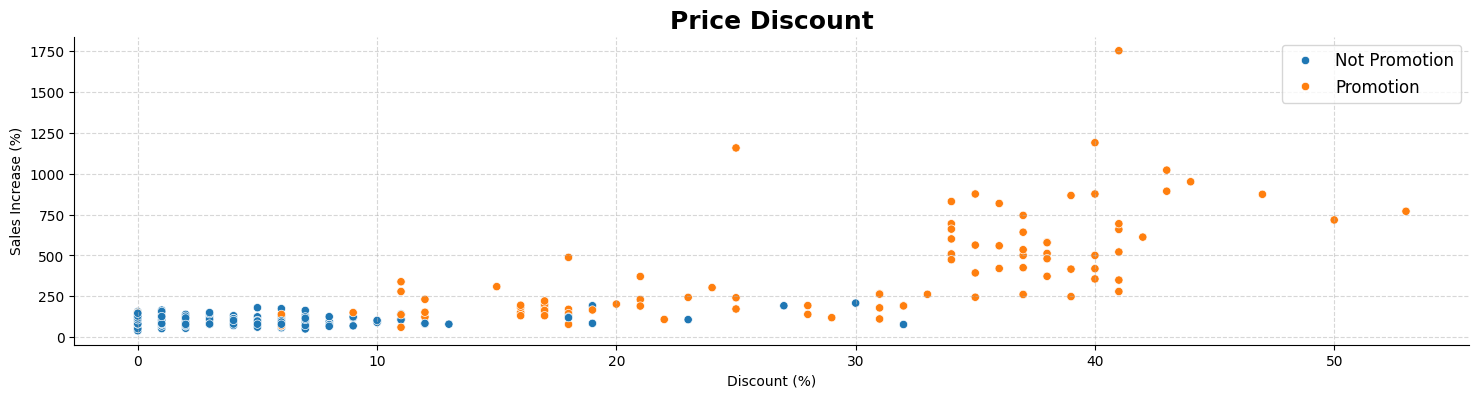

In [6]:
plt.figure(figsize = (18, 4))
sns.scatterplot(x = final_data.Discount, y = final_data.Ratio_Sales_Uplift, hue = final_data.Promotion) 
plt.title('Price Discount', fontsize = 18, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.ylabel('Sales Increase (%)')
plt.xlabel('Discount (%)')
plt.legend(fontsize = 12)
plt.show()

In [11]:
final_data_promotion = final_data.copy()
final_data_promotion = final_data_promotion[final_data_promotion.Promotion == 'Promotion']
final_data_promotion['log_y'] = np.log(final_data_promotion.Ratio_Sales_Uplift)

equation_no_promotion_data = final_data_promotion[['Discount', 'log_y']]
equation_no_promotion_data.head(3)

,Discount,log_y
8,50.0,6.575076
27,29.0,4.779123
60,43.0,6.929517


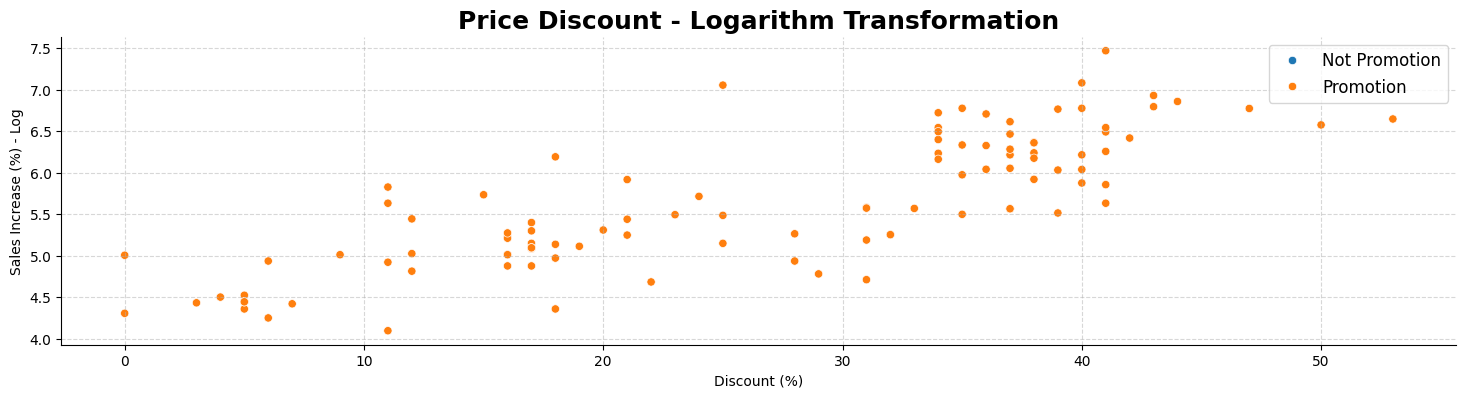

In [12]:
# y = a * e^bx
plt.figure(figsize = (18, 4))
sns.scatterplot(x = equation_no_promotion_data.Discount, y = equation_no_promotion_data.log_y, hue = final_data.Promotion) 
plt.title('Price Discount - Logarithm Transformation', fontsize = 18, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.ylabel('Sales Increase (%) - Log')
plt.xlabel('Discount (%)')
plt.legend(fontsize = 12)
plt.show()

### Linear Regression

In [13]:
from typing import Optional, Tuple
from sklearn.linear_model import LinearRegression

#equation_no_promotion_data['log_y'] = np.log(equation_no_promotion_data.Ratio_Sales_Uplift)


def log_linear_equation(data: pd.DataFrame, y_column: str, x_column: str, print_parameters: Optional[bool] = False) -> Tuple[float, float]:
    """
    Trains a linear regression model on the specified dataset columns
    Important: `y_column` is a logarithm of the `Ratio_Sales_Uplift` column
    Retrieves the coefficient and intercept from the trained global regression model.

    Args:
        data (pd.DataFrame): The input dataframe containing the data.
        y_column (str): The name of the target variable column (dependent variable).
        x_column (str): The name of the feature column (independent variable).

    Returns:
        Tuple[float, float]: A tuple containing the coefficient (slope) and the intercept.
    """
    X = data[[x_column]]
    y = data[y_column]    # log_y!

    model = LinearRegression()
    model.fit(X = X, y = y)
    
    coef, intercept = model.coef_[0], model.intercept_
    if print_parameters:
        print(f'Coef: {coef}, Intercept {intercept}')
    return coef, intercept


coef, intercept = log_linear_equation(data = equation_no_promotion_data, y_column = 'log_y', x_column = 'Discount', print_parameters = True)

Coef: 0.04850965647548331, Intercept 4.35538919452751


In [14]:
# plot
# y = coef * x + intercept
def linear_equation(x_input:float):
    return coef * x_input + intercept

x_range = range(int(np.min(equation_no_promotion_data.Discount)), int(np.max(equation_no_promotion_data.Discount)))
linear_curve: list = [linear_equation(element) for element in x_range]
print(linear_curve[:5])

[np.float64(4.35538919452751), np.float64(4.403898851002993), np.float64(4.452408507478477), np.float64(4.50091816395396), np.float64(4.549427820429443)]


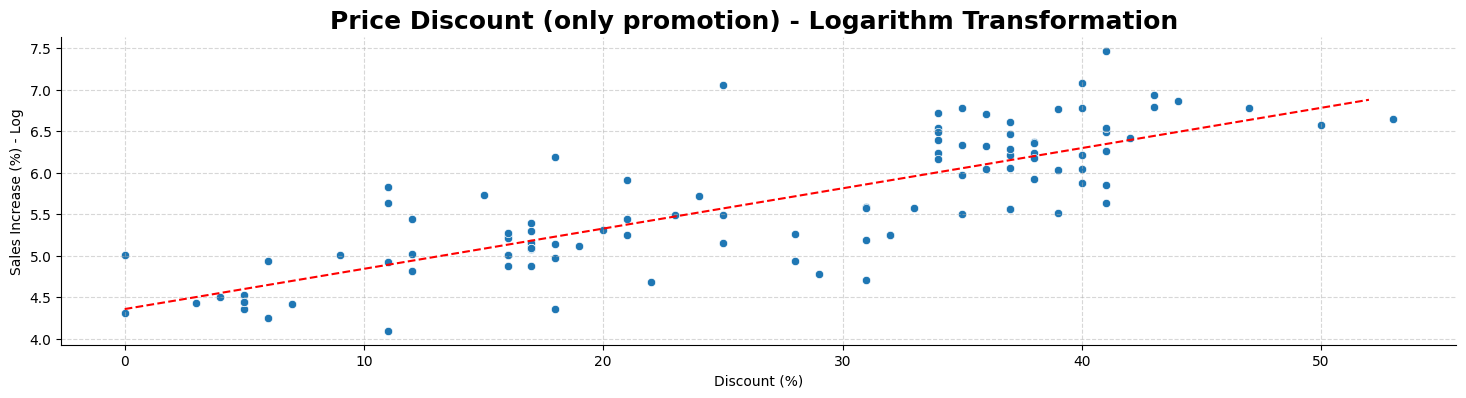

In [17]:
plt.figure(figsize = (18, 4))
sns.scatterplot(x = equation_no_promotion_data.Discount, y = equation_no_promotion_data.log_y) 
plt.plot(x_range, linear_curve, ls = '--', color = 'red')
plt.title('Price Discount (only promotion) - Logarithm Transformation ', fontsize = 18, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.ylabel('Sales Increase (%) - Log')
plt.xlabel('Discount (%)')
#plt.legend(fontsize = 12)
plt.show()

### Sales Predictions

In [21]:
def apply_prediction(coefficient: float, intercept: float, discount: int) -> float:
    return coef * discount + intercept


def denormalize_linear_equation(x_log: float) -> float:
    """
    Applies the exponential function to inverse a natural log transformation.

    Args:
        x_log (float): The log-transformed value.

    Returns:
        float: The value converted back to the original scale.
    """
    return np.exp(x_log)


def pred_multiplier(coef: float, intercept: float, discount: int) -> float:
     """
     Predicts the sales multiplier for a given discount using the exponential model.

     Args:
         discount (float): The discount percentage.

     Returns:
         float: The predicted multiplier, rounded to 2 decimal places.
     """
     return np.round(denormalize_linear_equation(apply_prediction(coefficient = coef, intercept = intercept, discount = discount)) / 100, 4)



def pred_total_sales(coef: float, intercept: float, discount: int, baseline_sales: float) -> float:
     """
     Calculates the projected total sales by applying the predicted multiplier to a baseline.

     Args:
         discount (int): The discount percentage.
         baseline_price (float, optional): The baseline sales value. Defaults to 1.8.

     Returns:
         float: The projected total sales, rounded to 2 decimal places.
     """
     return np.floor(baseline_sales * pred_multiplier(coef, intercept, discount = discount))



BASELINE_UNIT_COST: float = hp_filter_price.mean()  # n
BASELINE_SALES_VOLUMES: float = hp_filter_sales.mean()    # m

print(f'Baseline Unit Cost: {BASELINE_UNIT_COST:.4f}')
print(f'Baseline Sales Volumes: {BASELINE_SALES_VOLUMES:.4f}')

Baseline Unit Cost: 1.6513
Baseline Sales Volumes: 49.2488


In [ ]:
# Exemple wit discount = 20%
DISCOUNT: int = 20

# 1. Find the Multplier
multiplier: float = pred_multiplier(coef = coef, intercept = intercept, discount = DISCOUNT)
print('Multiplier for 20% Discount:', multiplier)

# OR find directly the sales predictions
total_sales = pred_total_sales(coef = coef, intercept = intercept, discount = DISCOUNT, baseline_sales = BASELINE_SALES_VOLUMES)
print('Total Sales Predictions:', total_sales, 'units.')

Multiplier for 20% Discount: 2.0553
Total Sales Predictions: 101.0 units.


**Tester les plusieurs models et prendre la plus basse MAE**